In [6]:
# libraries 

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

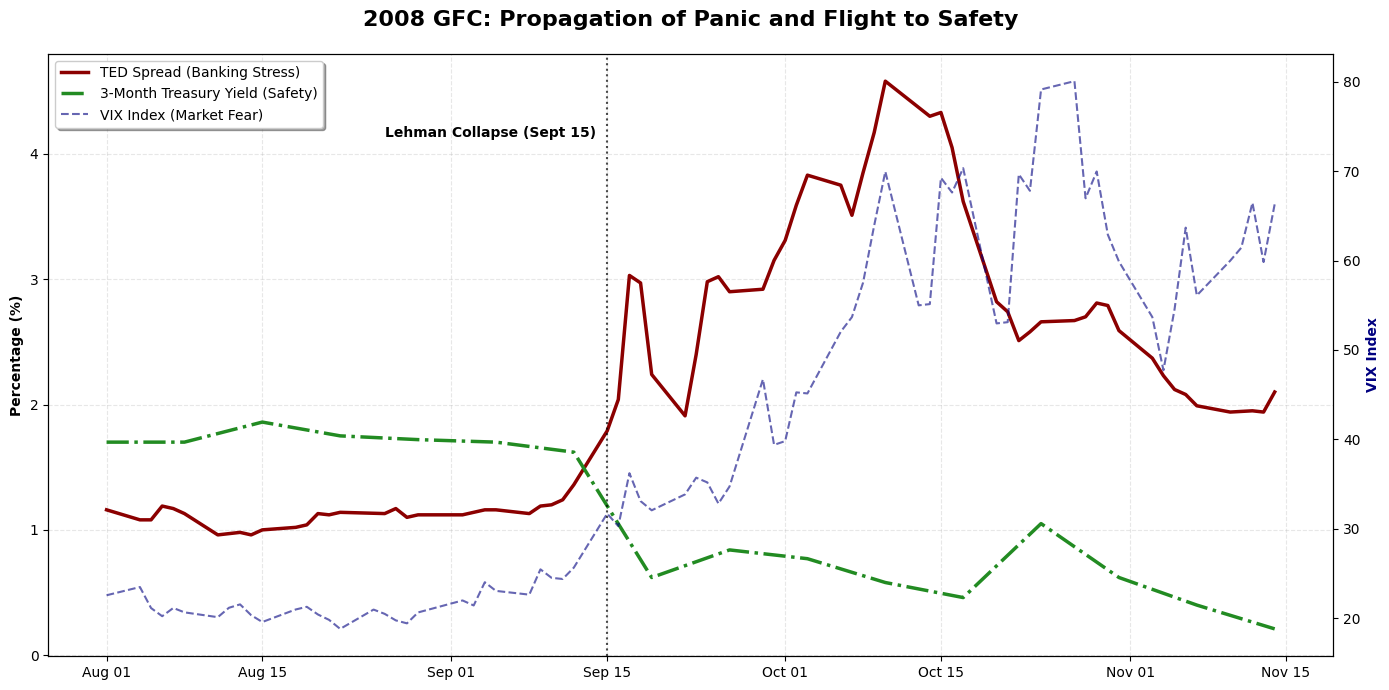

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load the processed datasets
ted_df = pd.read_csv('../datasets/processed/gfc_data/processed_TEDRATE.csv')
vix_df = pd.read_csv('../datasets/processed/gfc_data/processed_^VIX.csv')
wgs_df = pd.read_csv('../datasets/processed/gfc_data/processed_WGS3MO.csv')

# 2. Standardize dates
ted_df['date'] = pd.to_datetime(ted_df['date_standardized'])
vix_df['date'] = pd.to_datetime(vix_df['date_standardized'])
wgs_df['date'] = pd.to_datetime(wgs_df['date_standardized'])

# 3. Drop NaNs to fix "disconnected" gaps
ted_clean = ted_df.dropna(subset=['TEDRATE'])
vix_clean = vix_df.dropna(subset=['Close'])
wgs_clean = wgs_df.dropna(subset=['WGS3MO'])

# 4. Filter for the peak panic window
start, end = '2008-08-01', '2008-11-15'
ted_p = ted_clean[ted_clean['date'].between(start, end)]
vix_p = vix_clean[vix_clean['date'].between(start, end)]
wgs_p = wgs_clean[wgs_clean['date'].between(start, end)]

# 5. Create Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis (Left): Percentages (%) for TED and Treasury Yields
lns1 = ax1.plot(ted_p['date'], ted_p['TEDRATE'], color='darkred', label='TED Spread (Banking Stress)', linewidth=2.5)
lns3 = ax1.plot(wgs_p['date'], wgs_p['WGS3MO'], color='forestgreen', label='3-Month Treasury Yield (Safety)', linewidth=2.5, linestyle='-.')
ax1.set_ylabel('Percentage (%)', color='black', fontweight='bold')

# Secondary Axis (Right): VIX Index
ax2 = ax1.twinx()
lns2 = ax2.plot(vix_p['date'], vix_p['Close'], color='navy', linestyle='--', label='VIX Index (Market Fear)', alpha=0.6)
ax2.set_ylabel('VIX Index', color='navy', fontweight='bold')

# 6. Lehman Annotation (Left Aligned)
lehman_date = pd.to_datetime('2008-09-15')
plt.axvline(x=lehman_date, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
plt.text(lehman_date - pd.Timedelta(days=1), 75, 'Lehman Collapse (Sept 15)', 
         va='top', ha='right', fontweight='bold', fontsize=10)

# 7. Legend & Formatting
lns = lns1 + lns3 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title("2008 GFC: Propagation of Panic and Flight to Safety", fontsize=16, fontweight='bold', pad=20)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

Chart focusing strictly on 2008 saved as: gfc_2008_propagation.png


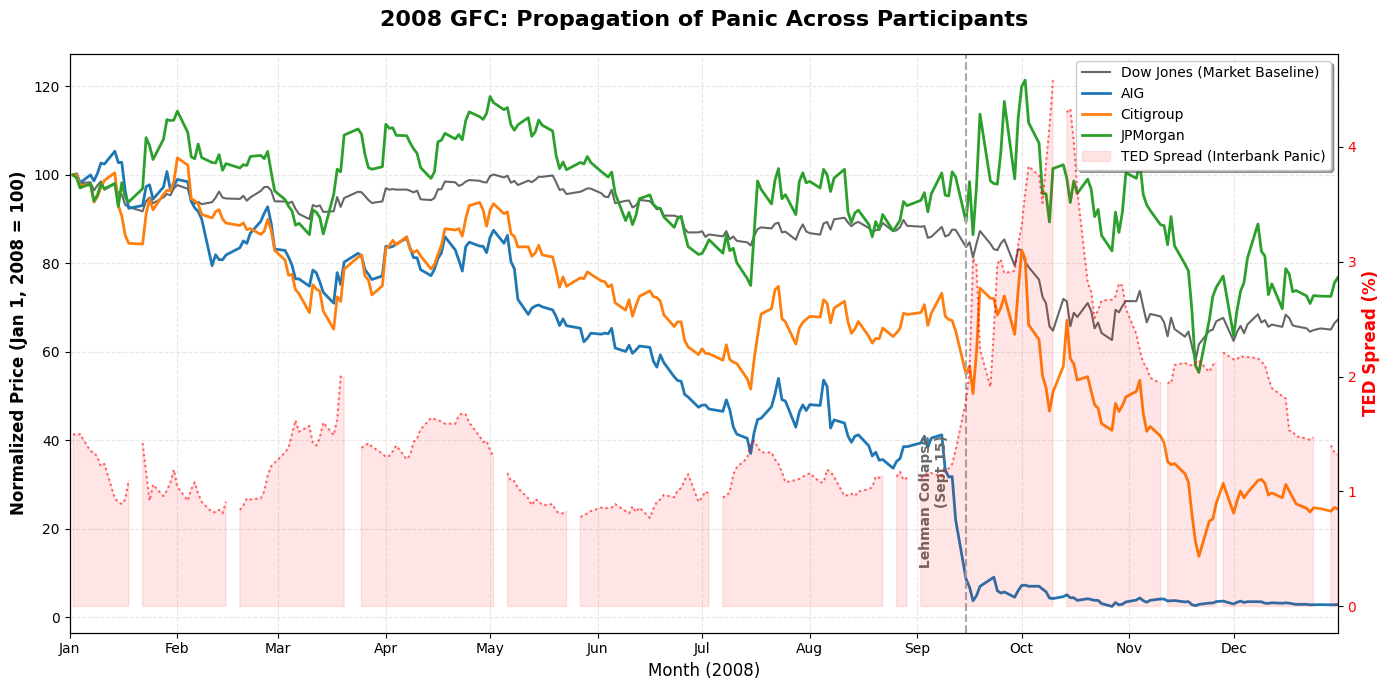

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the participant and indicator data
files = {
    'DJI': '../datasets/processed/gfc_data/processed_^DJI.csv',
    'GSPC': '../datasets/processed/gfc_data/processed_^GSPC.csv',
    'VIX': '../datasets/processed/gfc_data/processed_^VIX.csv',
    'AIG': '../datasets/processed/gfc_data/processed_AIG.csv',
    'Citi': '../datasets/processed/gfc_data/processed_C.csv',
    'JPM': '../datasets/processed/gfc_data/processed_JPM.csv',
    'DJI': '../datasets/processed/gfc_data/processed_^DJI.csv',
    'TED': '../datasets/processed/gfc_data/processed_TEDRATE.csv',
    'WGS3MO': '../datasets/processed/gfc_data/processed_WGS3MO.csv'
}

data = {}
for name, path in files.items():
    df = pd.read_csv(path)
    # Using the date column created in your pipeline
    df['date'] = pd.to_datetime(df['date_standardized'])
    data[name] = df.dropna(subset=['date'])

# Focus strictly on the year 2008
focus_start = '2008-01-01'
focus_end = '2008-12-31'

# Normalize function with strict start and end clipping
def normalize_and_clip(df, start, end):
    subset = df[(df['date'] >= start) & (df['date'] <= end)].sort_values('date').copy()
    if not subset.empty:
        # Normalize to 100 at the very start of the focus period (Jan 2008)
        initial_val = subset.iloc[0]['Close']
        subset['norm'] = (subset['Close'] / initial_val) * 100
    return subset

# Apply normalization and clipping
aig_2008 = normalize_and_clip(data['AIG'], focus_start, focus_end)
citi_2008 = normalize_and_clip(data['Citi'], focus_start, focus_end)
jpm_2008 = normalize_and_clip(data['JPM'], focus_start, focus_end)
dji_2008 = normalize_and_clip(data['DJI'], focus_start, focus_end)
ted_2008 = data['TED'][(data['TED']['date'] >= focus_start) & (data['TED']['date'] <= focus_end)]

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Plot Participant Performance (Left Axis)
ax1.plot(dji_2008['date'], dji_2008['norm'], color='black', linewidth=1.5, label='Dow Jones (Market Baseline)', alpha=0.6)
ax1.plot(aig_2008['date'], aig_2008['norm'], label='AIG', linewidth=2)
ax1.plot(citi_2008['date'], citi_2008['norm'], label='Citigroup', linewidth=2)
ax1.plot(jpm_2008['date'], jpm_2008['norm'], label='JPMorgan', linewidth=2)

ax1.set_ylabel('Normalized Price (Jan 1, 2008 = 100)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month (2008)', fontsize=12)

# 2. Plot TED Spread (Right Axis) - The Panic Indicator
ax2 = ax1.twinx()
ax2.fill_between(ted_2008['date'], ted_2008['TEDRATE'], color='red', alpha=0.1, label='TED Spread (Interbank Panic)')
ax2.plot(ted_2008['date'], ted_2008['TEDRATE'], color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.set_ylabel('TED Spread (%)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

# 3. Lehman Annotation (Moved Left of Sept 15)
lehman_date = pd.to_datetime('2008-09-15')
ax1.axvline(x=lehman_date, color='darkgray', linestyle='--', linewidth=1.5)
ax1.text(lehman_date - pd.Timedelta(days=5), 10, ' Lehman Collapse\n (Sept 15)', 
         rotation=90, va='bottom', ha='right', color='dimgray', fontweight='bold')

# 4. Strict X-Axis Focus
ax1.set_xlim(pd.to_datetime(focus_start), pd.to_datetime(focus_end))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# 5. Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, shadow=True)

plt.title("2008 GFC: Propagation of Panic Across Participants", fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout()
plt.savefig('gfc_2008_propagation.png')
print("Chart focusing strictly on 2008 saved as: gfc_2008_propagation.png")